<a href="https://colab.research.google.com/github/korhankoz/so_survey_analysis/blob/main/Untitled18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

Stackoverflow 2025 Developer Surveys - Job Satisfaction Classification and Deepdive
---

# Cross Industry Standard Process for Data Mining (CRISP-DM)
**1.   Business Understanding:**
This data consists various answers from developers and has a Job Satisfaction part. We will try to see if we can find some features that shows a strong bond with Job Satisfaction, espacially AI related questions and Job Satisfaction correlation interests me. The goal is to understand current job satisfaction conditions and AI stance, this EDA might be more insightful when repeated for 2026 survey (AI is clearly getting bigger each day in dev community. Not just as a new tech talk, but as where is my job heading talk.)

**Questions**:

-Do developers who actively use AI tools have higher job satisfaction or the other way?

-Which AI related  behaviours and attitudes are strongest predictors for Job Satisfaction?

-Can we build a simple classification model to predict job satisfaction of a developer?


**2.   Data Understanding:**

StackOverflow Developer Survey dataset contains 49,191 responses and 172 columns.
Topics: developer demographics, work environment, compensation, technology usage, and attitudes toward AI.

Our target var -> JobSat a numeric score ranging from 0 to 10 representing overall job satisfaction. I turned this into a categoric variable later on Low, Med and High satisfaction. This will be our target variable for both model and analysis.

**3.   Prepare Data:**

22,521 responses (%46) had no JobSat value and were excluded from modeling, leaving 26,670 usable rows. Null Feature rows are handled using median for numeric features and filling with Unknown for categorical features. Categoric features are encoded fro RandomForestModel. See details in code.

**4.   Modelling & Evaluation:**

The model achieves 52% overall accuracy — significantly above the 33% which is random selection. Classification success rate of three satisfaction categories are ranked: High>Medium>Low, reason is lack of low scorers in the dataset. We can tell from our model results, Job Satisfaction is really a complex KPI which cant be derived only from demographics. It is affacted developer's feeling at a certain time, also being satisfied can be related to where you start or what you aim.



In [19]:
# Load data from csv from both schema and full data
schema = pd.read_csv('survey_results_schema.csv')
df = pd.read_csv('survey_results_public.csv',
                 encoding='utf-8',
                 engine='python',
                 on_bad_lines='warn')

print(df.shape)
print(schema.head())

/tmp/ipykernel_351/1975390437.py:3: ParserWarning: Skipping line 5196: field larger than field limit (131072)

  df = pd.read_csv('survey_results_public.csv',


(49190, 172)
     qid          qname                                           question  \
0  QID18  TechEndorse_1  What attracts you to a technology or causes yo...   
1  QID18  TechEndorse_2  What attracts you to a technology or causes yo...   
2  QID18  TechEndorse_3  What attracts you to a technology or causes yo...   
3  QID18  TechEndorse_4  What attracts you to a technology or causes yo...   
4  QID18  TechEndorse_5  What attracts you to a technology or causes yo...   

  type                                      sub  sq_id  
0   RO  AI integration or AI Agent capabilities    1.0  
1   RO                          Easy-to-use API    2.0  
2   RO                  Robust and complete API    3.0  
3   RO     Customizable and manageable codebase    4.0  
4   RO                   Reputation for quality    5.0  


**Loading + Data Prep**


In [20]:
# Check job satisfaction values
print(df['JobSat'].value_counts()) #Most are satisfied, showing high numbers
print("\nMissing values:", df['JobSat'].isna().sum()) #22,521 missing answers on our question

JobSat
8.0     6972
7.0     5590
9.0     3598
6.0     3230
10.0    2924
5.0     1896
3.0      811
4.0      803
2.0      439
0.0      242
1.0      165
Name: count, dtype: int64

Missing values: 22520


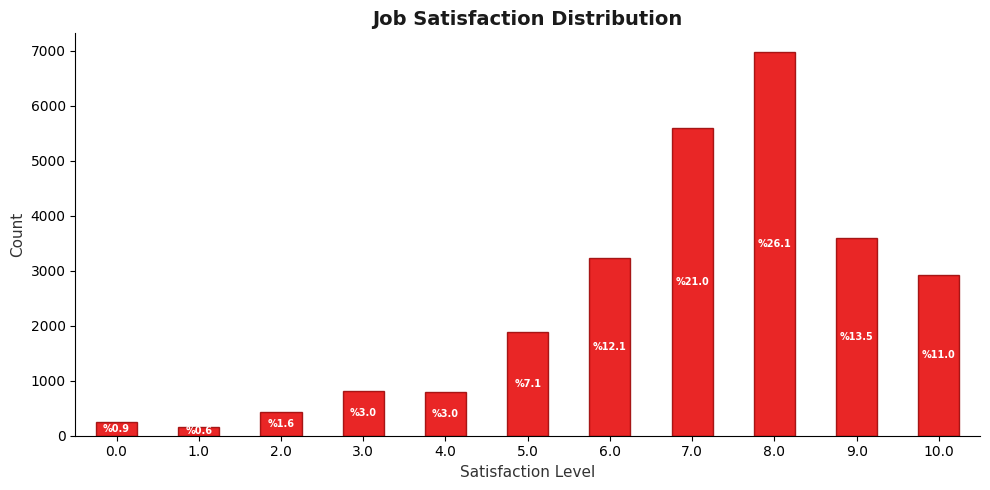

In [21]:
#JobSat Distribution plot
plt.figure(figsize=(10,5))
ax = df['JobSat'].value_counts().sort_index().plot(
    kind='bar',
    color='#E60000',
    edgecolor='#990000',
    alpha=0.85
)

total = df['JobSat'].value_counts().sum()
for p in ax.patches:
    percentage = f"%{p.get_height() / total * 100:.1f}"
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center',
                fontsize=7, fontweight='bold', color='white')

plt.title('Job Satisfaction Distribution', fontsize=14, fontweight='bold', color='#1a1a1a')
plt.xlabel('Satisfaction Level', fontsize=11, color='#333333')
plt.ylabel('Count', fontsize=11, color='#333333')
plt.xticks(rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [22]:
#print(df.columns.tolist())

#Dropping NA Target rows, we cant guess or fill them without interfering with results
df = df.dropna(subset=['JobSat'])

#Features we will use and df for our model
features = [
    # Personal & Career
    'Age',
    'EdLevel',
    'YearsCode',
    'WorkExp',
    'DevType',
    'ICorPM',           # Individual contributor or people manager

    # Work environment
    'Employment',
    'RemoteWork',
    'OrgSize',
    'Industry',

    # Compensation
    'ConvertedCompYearly',

    # AI attitude (2025-specific, very interesting!)
    'AISelect',         # Do they use AI tools?
    'AISent',           # Sentiment toward AI
    'AIThreat',         # Do they feel threatened by AI?

    # Target
    'JobSat'
]

df_model = df[features].copy()

# Turn Job Satisfaction Scores to categories low,med,high. This will be our new target to predict.
def categorize_satisfaction(score):
    if score <= 4:
        return 'Low'
    elif score <= 7:
        return 'Medium'
    else: return 'High'

df_model['JobSatCategory'] = df_model['JobSat'].apply(categorize_satisfaction)
print(df_model['JobSatCategory'].value_counts())

print(df_model.shape)

JobSatCategory
High      13494
Medium    10716
Low        2460
Name: count, dtype: int64
(26670, 16)


In [23]:
#print(df_model.isna().sum())
#print(df_model.dtypes)

# Fill numeric missing values with median
numeric_cols = ['YearsCode', 'WorkExp', 'ConvertedCompYearly']
for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Fill categorical missing values with 'Unknown'
categorical_cols = ['EdLevel', 'ICorPM', 'RemoteWork', 'OrgSize',
                    'Industry', 'AISelect', 'AISent', 'AIThreat']
for col in categorical_cols:
    df_model[col] = df_model[col].fillna('Unknown')

print("Missing values after cleaning:")
print(df_model.isna().sum())

Missing values after cleaning:
Age                    0
EdLevel                0
YearsCode              0
WorkExp                0
DevType                0
ICorPM                 0
Employment             0
RemoteWork             0
OrgSize                0
Industry               0
ConvertedCompYearly    0
AISelect               0
AISent                 0
AIThreat               0
JobSat                 0
JobSatCategory         0
dtype: int64


In [24]:
from sklearn.preprocessing import LabelEncoder
#encode categoric features for model
le = LabelEncoder()
for col in categorical_cols + ['Age', 'DevType', 'Employment']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(df_model.dtypes)

Age                      int64
EdLevel                  int64
YearsCode              float64
WorkExp                float64
DevType                  int64
ICorPM                   int64
Employment               int64
RemoteWork               int64
OrgSize                  int64
Industry                 int64
ConvertedCompYearly    float64
AISelect                 int64
AISent                   int64
AIThreat                 int64
JobSat                 float64
JobSatCategory          object
dtype: object


**Business Questions**

-Do developers who actively use AI tools have higher job satisfaction or the other way?

Answer: Daily AI Users (which is the most freq usage category) have the highest High Scorer Rate 52.2 and the lowest Low Scorer Rate 8.4. **So More AI Usage seems to be geting slightly better Job Satisfaction results.** But since the differences are not so drastic we cant say AI usage alone determines the satisfaction.

JobSatCategory                                Low  Medium  High
AISelect                                                       
No, and I don't plan to                      10.8    38.5  50.7
No, but I plan to soon                       10.2    39.7  50.0
Yes, I use AI tools monthly or infrequently  10.0    40.9  49.1
Yes, I use AI tools weekly                    9.0    42.6  48.4
Yes, I use AI tools daily                     8.4    39.4  52.2


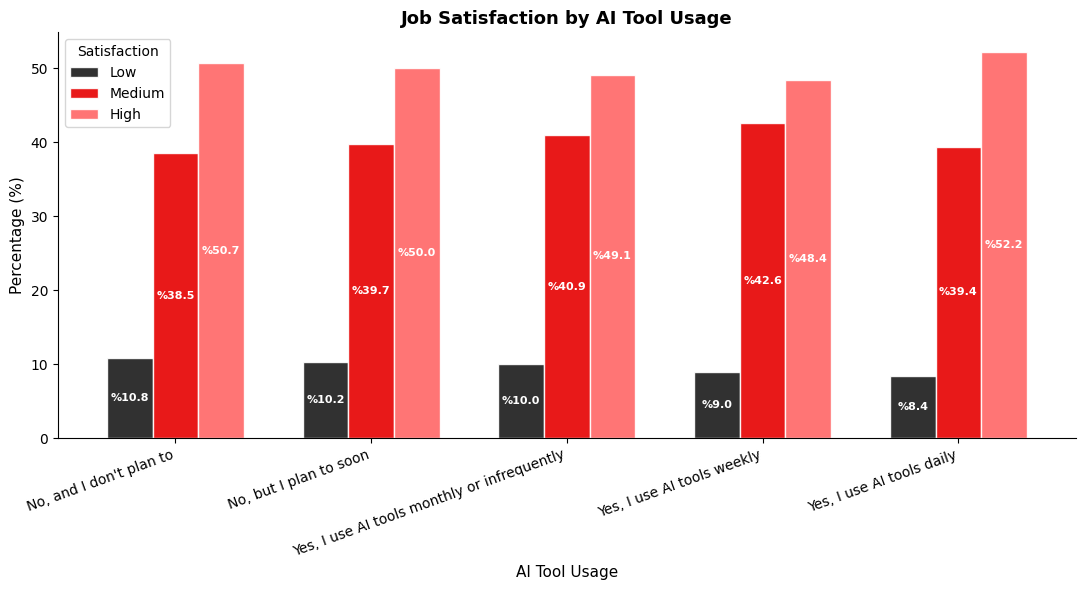

In [27]:
# Define correct order
ai_order = [
    'No, and I don\'t plan to',
    'No, but I plan to soon',
    'Yes, I use AI tools monthly or infrequently',
    'Yes, I use AI tools weekly',
    'Yes, I use AI tools daily'
]

ai_sat = df[['AISelect', 'JobSat']].dropna()
ai_sat = ai_sat[ai_sat['AISelect'].isin(ai_order)]

ai_sat['JobSatCategory'] = ai_sat['JobSat'].apply(categorize_satisfaction)

ai_pct = (ai_sat.groupby(['AISelect', 'JobSatCategory'])
          .size()
          .unstack()
          .apply(lambda x: x / x.sum() * 100, axis=1)
          [['Low', 'Medium', 'High']])

ai_pct = ai_pct.reindex(ai_order)
print(ai_pct.round(1))

ax = ai_pct.plot(
    kind='bar', figsize=(11, 6),
    color=['#1a1a1a', '#E60000', '#ff6666'],
    edgecolor='white', alpha=0.9, width=0.7
)

for p in ax.patches:
    if p.get_height() > 2:
        ax.annotate(f"%{p.get_height():.1f}",
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')

plt.title('Job Satisfaction by AI Tool Usage', fontweight='bold', fontsize=13)
plt.xlabel('AI Tool Usage', fontsize=11)
plt.ylabel('Percentage (%)', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Satisfaction', labels=['Low', 'Medium', 'High'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

-Which AI related behaviours and attitudes are strongest predictors for Job Satisfaction?

Answer: None of the correlation coefficient values show strong correlation not in the 2025 survey at least. AIThreat (-0.073) is the strongest AI related feature.But still approximately two thousand developers  feel threatened by AI and compared to other answer groups they feel less satisfied.

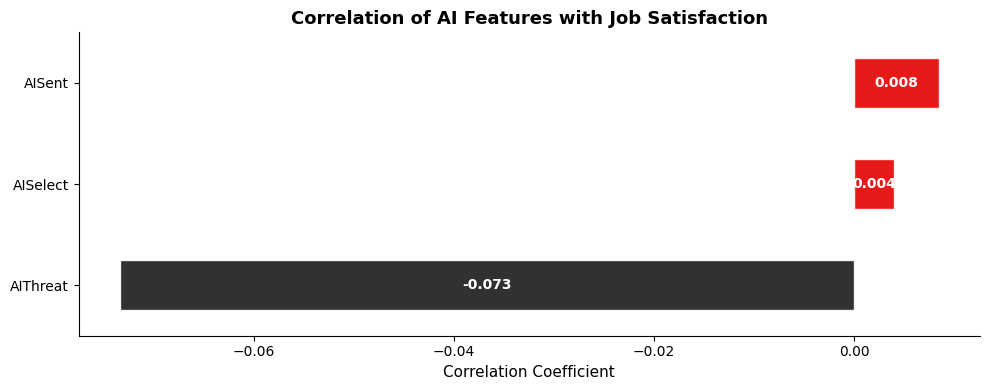

In [28]:
# Correlation of AI features with JobSat
ai_features = ['AISelect', 'AISent', 'AIThreat']

# Use encoded df_model for correlation
ai_corr = df_model[ai_features + ['JobSat']].corr()['JobSat'].drop('JobSat').sort_values()

ax = ai_corr.plot(
    kind='barh', figsize=(10, 4),
    color=['#1a1a1a' if v < 0 else '#E60000' for v in ai_corr.values],
    edgecolor='white', alpha=0.9
)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}",
                (p.get_width() / 2, p.get_y() + p.get_height() / 2),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

plt.title('Correlation of AI Features with Job Satisfaction', fontweight='bold', fontsize=13)
plt.xlabel('Correlation Coefficient', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

-Can we build a simple classification model to predict job satisfaction of a developer?

**Modelling**

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df_model.drop(['JobSat', 'JobSatCategory'], axis=1)
y = df_model['JobSatCategory']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# class_weight='balanced' compensates for the low number of 'Low' satisfaction responses
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.52

Classification Report:
              precision    recall  f1-score   support

        High       0.57      0.65      0.61      2683
         Low       0.24      0.07      0.10       498
      Medium       0.47      0.46      0.46      2153

    accuracy                           0.52      5334
   macro avg       0.43      0.39      0.39      5334
weighted avg       0.50      0.52      0.50      5334



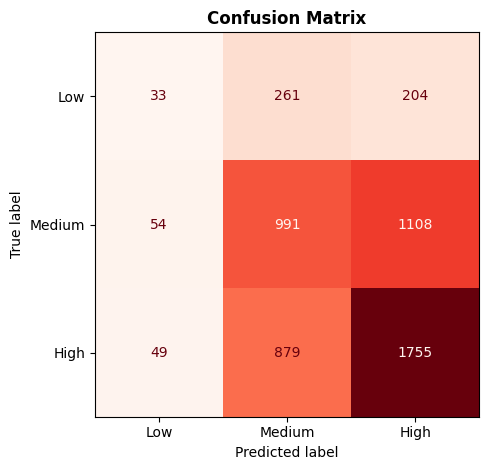

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=['Low', 'Medium', 'High'],
    cmap='Reds',
    colorbar=False
)
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
#We can see "Low" label prediction has the lowest accuracy

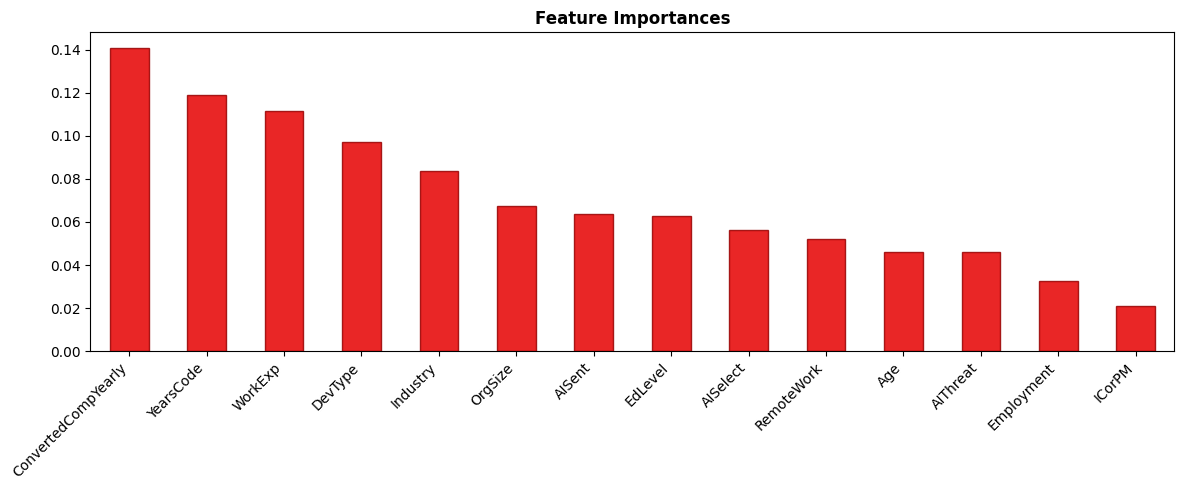

In [35]:
# Feature Importance - what drives job satisfaction the most?
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(
    kind='bar', figsize=(12,5), color='#E60000', edgecolor='#990000', alpha=0.85
)
plt.title('Feature Importances', fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

"Imagine a new scenario that requires a prediction from your model to answer. Describe the scenario in your post and run a prediction from the model."

In [34]:
# Scenario: Alex - 25-34 y/o backend developer, remote, $85k salary
# Uses AI daily but feels threatened by it and has unfavorable AI sentiment
# Prediction: HIGH satisfaction (37.2%) — but Medium is close at 35.8%

# Like we discussed in the modelling part, AI Threat doesn't change the outcome by itself.
#It absolutely can be better and more detailed but overall satisfaction about the job can't be predicted with what data we have.

from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Rebuild label encoders in same order as training
le = LabelEncoder()
encodings = {}
for col in categorical_cols + ['Age', 'DevType', 'Employment']:
    le.fit(df[col].astype(str))
    encodings[col] = {val: idx for idx, val in enumerate(le.classes_)}

# Build Alex's profile
alex = {
    'Age':                  encodings['Age']['25-34 years old'],
    'EdLevel': encodings['EdLevel']['Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)'],
    'YearsCode':            10.0,
    'WorkExp':              8.0,
    'DevType':              encodings['DevType']['Developer, back-end'],
    'ICorPM':               encodings['ICorPM']['Individual contributor'],
    'Employment':           encodings['Employment']['Employed'],
    'RemoteWork':           encodings['RemoteWork']['Remote'],
    'OrgSize':              encodings['OrgSize']['10,000 or more employees'],
    'Industry':             encodings['Industry']['Software Development'],
    'ConvertedCompYearly':  85000.0,
    'AISelect':             encodings['AISelect']['Yes, I use AI tools daily'],
    'AISent':               encodings['AISent']['Unfavorable'],
    'AIThreat':             encodings['AIThreat']['Yes'],
}

alex_df = pd.DataFrame([alex])
prediction = clf.predict(alex_df)[0]
proba = clf.predict_proba(alex_df)[0]
classes = clf.classes_

print(f"Predicted Job Satisfaction: {prediction}")
print("\nProbability breakdown:")
for cls, prob in zip(classes, proba):
    print(f"  {cls}: %{prob*100:.1f}")

Predicted Job Satisfaction: High

Probability breakdown:
  High: %37.2
  Low: %27.0
  Medium: %35.8
